In [55]:
# import necessary libraries
import pandas as pd # for data manipulation and analysis
import numpy as np # for numerical operations
from sklearn.model_selection import train_test_split # for splitting the dataset into training and testing sets
from sklearn.preprocessing import StandardScaler # for feature scaling
from sklearn.linear_model import LinearRegression # for linear regression model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
    )# for model evaluation
import matplotlib.pyplot as plt # for data visualization

In [56]:
# create a sample dataset
data = {
    "hours_studied": [2, 3, 5, 7, 8, 4, 6, 1, 9, 10],
    "attendance": [70, 75, 85, 90, 95, 80, 88, 65, 97, 99],
    "previous_marks": [45, 50, 65, 75, 80, 60, 70, 40, 85, 92],
    "final_marks": [50, 58, 72, 84, 90, 68, 80, 42, 94, 98]
} # create a DataFrame from the dictionary
df = pd.DataFrame(data) 
print("Dataset:")
print(df) # display the dataset

Dataset:
   hours_studied  attendance  previous_marks  final_marks
0              2          70              45           50
1              3          75              50           58
2              5          85              65           72
3              7          90              75           84
4              8          95              80           90
5              4          80              60           68
6              6          88              70           80
7              1          65              40           42
8              9          97              85           94
9             10          99              92           98


In [57]:
# split the dataset into features and target variable
x = df[["hours_studied", "attendance", "previous_marks"]] # features
y = df["final_marks"] # target variable

In [58]:
# train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) # split the dataset into training and testing sets

In [59]:
# feature scaling
scaler = StandardScaler() # create a StandardScaler object
x_train = scaler.fit_transform(x_train) # fit and transform the training data
x_test = scaler.transform(x_test) # transform the testing data

In [60]:
# create and train the linear regression model
model = LinearRegression() # create a LinearRegression object
model.fit(x_train, y_train) # train the model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-3.67,12.71, 8.97]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,73
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[4.89,0.33,0.12]"


In [61]:
# make predictions on the test set
predictions = model.predict(x_test) # make predictions on the test set
print("Predictions:", predictions) # display the predictions

Predictions: [93.81377639 56.96573209]


In [62]:
# evaluate the model
mae = mean_absolute_error(y_test, predictions) # calculate mean absolute error
print("Mean Absolute Error:", mae) # display mean absolute error
mse = mean_squared_error(y_test, predictions) # calculate mean squared error
print("Mean Squared Error:", mse) # display mean squared error
rmse = np.sqrt(mse) # calculate root mean squared error
print("Root Mean Squared Error:", rmse) # display root mean squared error
r2 = r2_score(y_test, predictions) # calculate R-squared score
print("R-squared Score:", r2) # display R-squared score

Mean Absolute Error: 0.6102457597784721
Mean Squared Error: 0.5521946735573732
Root Mean Squared Error: 0.7430980241915418
R-squared Score: 0.9982956954519834


In [63]:
# make prediction for a new student
new_student = pd.DataFrame([{"hours_studied": 6, "attendance": 85, "previous_marks": 70}]) # create a new student data
new_student_scaled = scaler.transform(new_student) # scale the new student data

result = model.predict(new_student_scaled) # make prediction for the new student
print(f"Predicted final marks for a new student who studied {6} hours, had {85}% attendance, and scored {70} in previous exams: {result[0]:.2f}") # display the prediction

Predicted final marks for a new student who studied 6 hours, had 85% attendance, and scored 70 in previous exams: 75.61


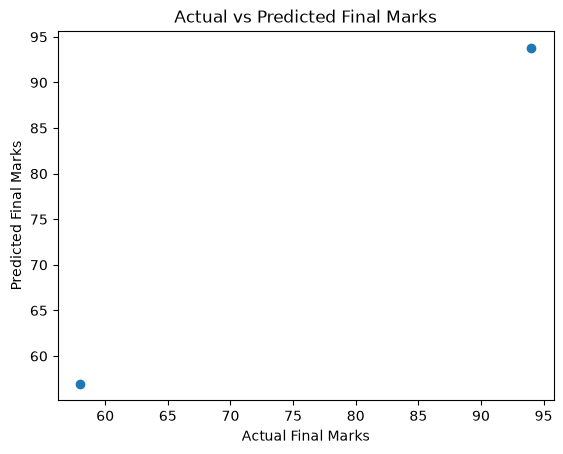

In [64]:
# visualize the results
plt.scatter(y_test, predictions) # create a scatter plot of actual vs predicted values
plt.xlabel("Actual Final Marks") # set x-axis label
plt.ylabel("Predicted Final Marks") # set y-axis label
plt.title("Actual vs Predicted Final Marks") # set plot title
plt.show() # display the plot